In [1]:
import sys
import pynetlogo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("All imports successful!")

All imports successful!


In [2]:
# NetLogo path for Windows
netlogo_path = r'C:\Program Files\NetLogo 6.2.0'

# Verify path exists
if os.path.exists(netlogo_path):
    print(f"✓ NetLogo found at: {netlogo_path}")
else:
    print("✗ NetLogo not found!")

# Connect to NetLogo (headless mode for reliability)
print("Connecting to NetLogo...")
netlogo = pynetlogo.NetLogoLink(gui=False, netlogo_home=netlogo_path)

print("✓ NetLogo connected!")

✓ NetLogo found at: C:\Program Files\NetLogo 6.2.0
Connecting to NetLogo...
✓ NetLogo connected!


In [3]:
# Load Wolf Sheep Predation model
model_path = netlogo_path + r'\app\models\Sample Models\Biology\Wolf Sheep Predation.nlogo'

# Check if model exists
if os.path.exists(model_path):
    print(f"✓ Model found at: {model_path}")
    netlogo.load_model(model_path)
    print("✓ Model loaded successfully!")
else:
    print("✗ Model not found, searching...")
    # Search for the model
    import glob
    models = glob.glob(netlogo_path + r'\**\Wolf Sheep Predation.nlogo', recursive=True)
    if models:
        print(f"Found model at: {models[0]}")
        netlogo.load_model(models[0])
        print("✓ Model loaded successfully!")

# Setup and test
netlogo.command('setup')
print(f"\nInitial state:")
print(f"  Sheep: {netlogo.report('count sheep')}")
print(f"  Wolves: {netlogo.report('count wolves')}")

✓ Model found at: C:\Program Files\NetLogo 6.2.0\app\models\Sample Models\Biology\Wolf Sheep Predation.nlogo
✓ Model loaded successfully!

Initial state:
  Sheep: 100.0
  Wolves: 50.0


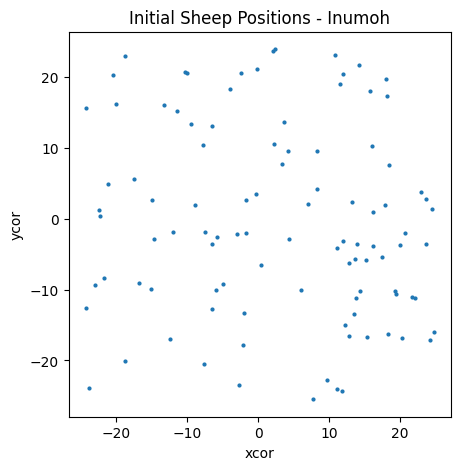

Initial positions plotted - Inumoh


In [5]:
# Get sheep coordinates (NetLogo 6 syntax)
x = netlogo.report('map [s -> [xcor] of s] sort sheep')
y = netlogo.report('map [s -> [ycor] of s] sort sheep')

# Plot initial positions
fig, ax = plt.subplots(1)
ax.scatter(x, y, s=4)
ax.set_xlabel('xcor')
ax.set_ylabel('ycor')
ax.set_title('Initial Sheep Positions - Inumoh')
ax.set_aspect('equal')
fig.set_size_inches(5, 5)
plt.show()

print("Initial positions plotted - Inumoh")

In [6]:
# Run for 100 ticks
netlogo.command('repeat 100 [go]')

# Get updated positions and energy (NetLogo 6 syntax)
x = netlogo.report('map [s -> [xcor] of s] sort sheep')
y = netlogo.report('map [s -> [ycor] of s] sort sheep')
energy_sheep = netlogo.report('map [s -> [energy] of s] sort sheep')
energy_wolves = netlogo.report('[energy] of wolves')

print(f"After 100 ticks - Inumoh:")
print(f"  Sheep count: {len(energy_sheep)}")
print(f"  Wolf count: {len(energy_wolves)}")

After 100 ticks - Inumoh:
  Sheep count: 244
  Wolf count: 270


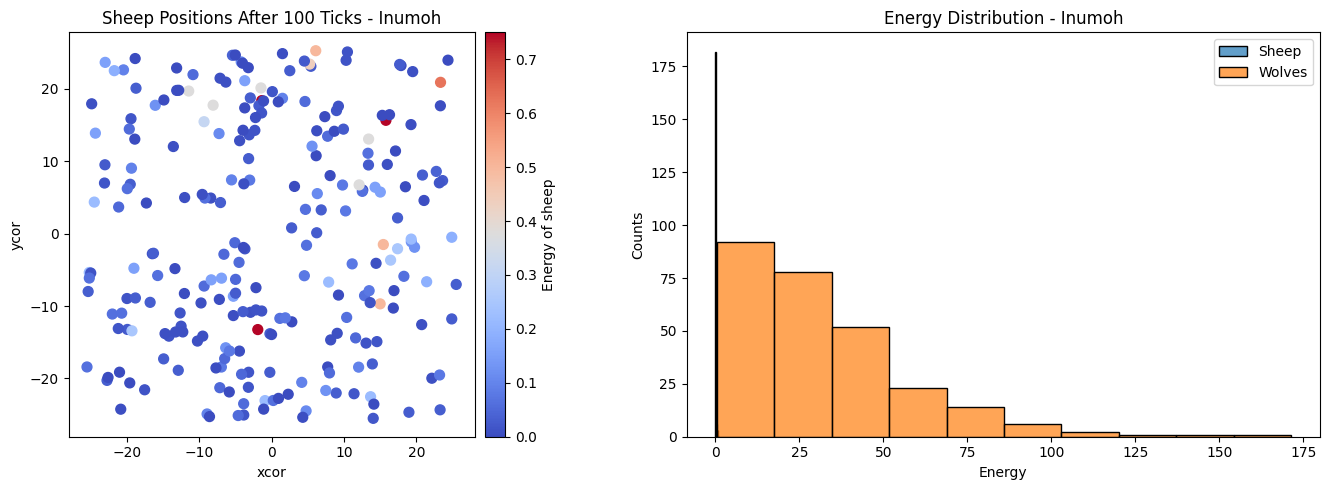

✓ Energy distribution plotted - Inumoh


In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 2)

# Scatter plot with energy colors
sc = ax[0].scatter(x, y, s=50, c=energy_sheep, cmap=plt.cm.coolwarm)
ax[0].set_xlabel('xcor')
ax[0].set_ylabel('ycor')
ax[0].set_title('Sheep Positions After 100 Ticks - Inumoh')
ax[0].set_aspect('equal')
divider = make_axes_locatable(ax[0])
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(sc, cax=cax, orientation='vertical')
cbar.set_label('Energy of sheep')

# Histogram of energy
sns.histplot(energy_sheep, kde=False, bins=10, ax=ax[1], label='Sheep', alpha=0.7)
sns.histplot(energy_wolves, kde=False, bins=10, ax=ax[1], label='Wolves', alpha=0.7)
ax[1].set_xlabel('Energy')
ax[1].set_ylabel('Counts')
ax[1].set_title('Energy Distribution - Inumoh')
ax[1].legend()

fig.set_size_inches(14, 5)
plt.tight_layout()
plt.show()

print("✓ Energy distribution plotted - Inumoh")

In [9]:
# Reset and track populations
netlogo.command('setup')
counts_data = netlogo.repeat_report(['count wolves', 'count sheep'], 200, go='go')

# Convert to DataFrame
counts = pd.DataFrame(counts_data)

print("\nPopulation Data - Inumoh")
print(counts.head(10))
print("\n...")
print(counts.tail(10))


Population Data - Inumoh
   count wolves  count sheep
0          50.0        100.0
1          51.0        103.0
2          53.0        106.0
3          55.0        106.0
4          50.0        109.0
5          53.0        109.0
6          54.0        116.0
7          57.0        120.0
8          57.0        121.0
9          58.0        124.0

...
     count wolves  count sheep
191          22.0          0.0
192          21.0          0.0
193          19.0          0.0
194          17.0          0.0
195          15.0          0.0
196          15.0          0.0
197          16.0          0.0
198          12.0          0.0
199          14.0          0.0
200           8.0          0.0


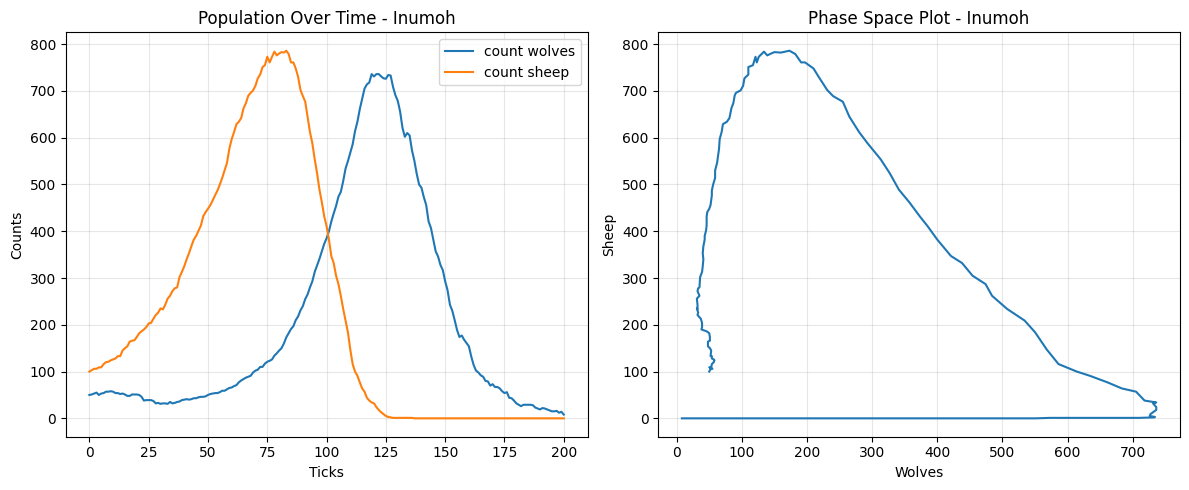

✓ Population dynamics plotted - Inumoh


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2)

# Time series
counts.plot(ax=ax1, use_index=True, legend=True)
ax1.set_xlabel('Ticks')
ax1.set_ylabel('Counts')
ax1.set_title('Population Over Time - Inumoh')
ax1.grid(True, alpha=0.3)

# Phase space plot
ax2.plot(counts['count wolves'], counts['count sheep'])
ax2.set_xlabel('Wolves')
ax2.set_ylabel('Sheep')
ax2.set_title('Phase Space Plot - Inumoh')
ax2.grid(True, alpha=0.3)

fig.set_size_inches(12, 5)
plt.tight_layout()
plt.show()

print("✓ Population dynamics plotted - Inumoh")


Energy Data Sample - Inumoh
                                  [energy] of wolves [energy] of sheep  \
0  [24.40625, 52.1875, 0.0234375, 5.328125, 0.023...                []   
1            [4.328125, 23.40625, 23.40625, 51.1875]                []   
2  [22.40625, 11.203125, 50.1875, 11.203125, 3.32...                []   
3  [49.1875, 10.203125, 21.40625, 10.203125, 2.32...                []   
4  [1.328125, 48.1875, 9.203125, 9.203125, 20.40625]                []   

   count sheep  count wolves  
0          0.0           6.0  
1          0.0           4.0  
2          0.0           5.0  
3          0.0           5.0  
4          0.0           5.0  


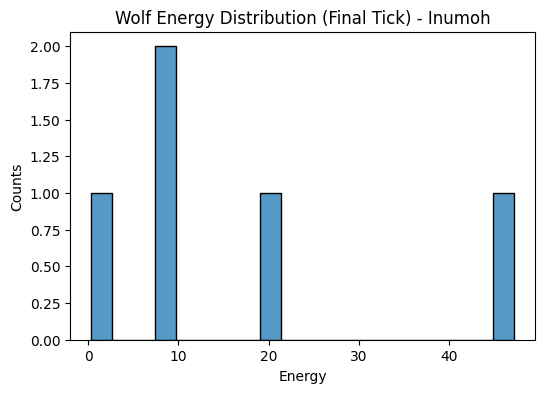

✓ Wolf energy plotted - Inumoh


In [12]:
energy_data = netlogo.repeat_report(['[energy] of wolves',
                                   '[energy] of sheep',
                                   'count sheep',
                                   'count wolves'], 5)

# Convert to DataFrame
energy_df = pd.DataFrame(energy_data)

print("\nEnergy Data Sample - Inumoh")
print(energy_df.head())

# Plot wolf energy distribution at final tick
fig, ax = plt.subplots(1)
sns.histplot(energy_df['[energy] of wolves'].iloc[-1], kde=False, bins=20, ax=ax)
ax.set_xlabel('Energy')
ax.set_ylabel('Counts')
ax.set_title('Wolf Energy Distribution (Final Tick) - Inumoh')
fig.set_size_inches(6, 4)
plt.show()

print("✓ Wolf energy plotted - Inumoh")


Patch Countdown Data - Inumoh
Shape: (51, 51)
    -25  -24  -23  -22  -21  -20  -19  -18  -17  -16  ...   16   17   18   19  \
25  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
24  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
23  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
22  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
21  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   

     20   21   22   23   24   25  
25  0.0  0.0  0.0  0.0  0.0  0.0  
24  0.0  0.0  0.0  0.0  0.0  0.0  
23  0.0  0.0  0.0  0.0  0.0  0.0  
22  0.0  0.0  0.0  0.0  0.0  0.0  
21  0.0  0.0  0.0  0.0  0.0  0.0  

[5 rows x 51 columns]


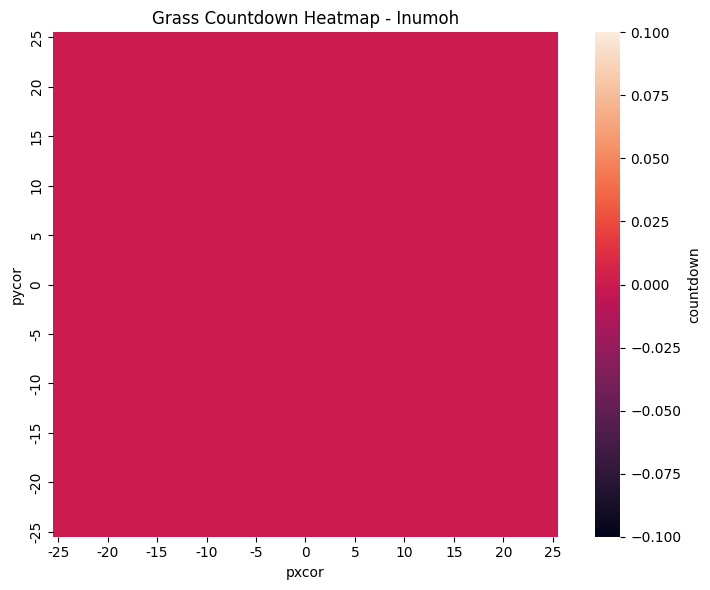

✓ Heatmap plotted - Inumoh


In [13]:
countdown_df = netlogo.patch_report('countdown')

print("\nPatch Countdown Data - Inumoh")
print(f"Shape: {countdown_df.shape}")
print(countdown_df.head())

fig, ax = plt.subplots(1)
patches = sns.heatmap(countdown_df, xticklabels=5, yticklabels=5,
                      cbar_kws={'label':'countdown'}, ax=ax)
ax.set_xlabel('pxcor')
ax.set_ylabel('pycor')
ax.set_title('Grass Countdown Heatmap - Inumoh')
ax.set_aspect('equal')
fig.set_size_inches(8, 6)
plt.tight_layout()
plt.show()

print("✓ Heatmap plotted - Inumoh")

In [14]:
print("\n" + "="*70)
print("SUMMARY STATISTICS - INUMOH")
print("="*70)
print("\nPopulation Statistics:")
print(counts.describe())

print("\n" + "="*70)
print("Final State - Inumoh:")
print(f"  Final Wolves: {counts['count wolves'].iloc[-1]}")
print(f"  Final Sheep: {counts['count sheep'].iloc[-1]}")
print(f"  Mean Wolves: {counts['count wolves'].mean():.2f}")
print(f"  Mean Sheep: {counts['count sheep'].mean():.2f}")
print("="*70)


SUMMARY STATISTICS - INUMOH

Population Statistics:
       count wolves  count sheep
count    201.000000   201.000000
mean     210.243781   235.303483
std      227.947374   268.452701
min        8.000000     0.000000
25%       46.000000     0.000000
50%       87.000000   126.000000
75%      341.000000   432.000000
max      736.000000   786.000000

Final State - Inumoh:
  Final Wolves: 8.0
  Final Sheep: 0.0
  Mean Wolves: 210.24
  Mean Sheep: 235.30


In [15]:
netlogo.kill_workspace()
print("✓ NetLogo workspace closed - Inumoh")

✓ NetLogo workspace closed - Inumoh
